# 3.3 总结：DeepFM、DIN 与 DIEN 排序

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

读取本章节每个独立算法 Notebook 的实际结果产物，在统一口径下比较和选型。

## Setup

本 Notebook 的默认真实数据是 **Amazon Reviews Electronics 5-core：DIN/DIEN 公开复现实验数据**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。

**主要资料：** DeepFM · DIN · DIEN 原始论文

In [1]:
from pathlib import Path
import os, sys, json
import torch
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.environ.setdefault("RECSYS_PROFILE", "full")
PROFILE = os.environ["RECSYS_PROFILE"]
CUDA_AVAILABLE = torch.cuda.is_available()
from recsys_lab.data import (load_movielens, movielens_provenance, load_amazon_2023,
                             amazon_provenance, load_kuairand, kuairand_provenance,
                             load_amazon_2018, amazon_2018_provenance,
                             load_movielens_1m, movielens_1m_provenance,
                             load_mind_amazon_books, mind_amazon_provenance,
                             load_census_income, census_income_provenance)
DATASET_KEY = "amazon-electronics"
if DATASET_KEY == "movielens":
    real_ratings, real_movies = load_movielens()
    real_interactions = real_ratings
    REAL_DATASET = movielens_provenance(real_ratings)
elif DATASET_KEY == "amazon-books":
    real_ratings = load_amazon_2018("Books") if PROFILE == "full" else load_amazon_2023()
    real_interactions, real_movies = real_ratings, None
    REAL_DATASET = amazon_2018_provenance(real_ratings) if PROFILE == "full" else amazon_provenance(real_ratings)
elif DATASET_KEY == "mind-amazon-books":
    real_ratings = load_mind_amazon_books() if PROFILE == "full" else load_amazon_2023()
    real_interactions, real_movies = real_ratings, None
    REAL_DATASET = mind_amazon_provenance(real_ratings) if PROFILE == "full" else amazon_provenance(real_ratings)
elif DATASET_KEY == "amazon-electronics":
    real_ratings = load_amazon_2018("Electronics") if PROFILE == "full" else load_amazon_2023()
    real_interactions, real_movies = real_ratings, None
    REAL_DATASET = amazon_2018_provenance(real_ratings) if PROFILE == "full" else amazon_provenance(real_ratings)
elif DATASET_KEY == "movielens-1m":
    real_ratings = load_movielens_1m() if PROFILE == "full" else load_amazon_2023()
    real_interactions, real_movies = real_ratings, None
    REAL_DATASET = movielens_1m_provenance(real_ratings) if PROFILE == "full" else amazon_provenance(real_ratings)
elif DATASET_KEY == "census-income" and PROFILE == "full":
    census_train_x, census_train_y, census_test_x, census_test_y = load_census_income()
    real_interactions, real_movies, real_ratings = census_train_x, None, census_train_x
    REAL_DATASET = census_income_provenance()
elif DATASET_KEY == "amazon-2023":
    real_ratings = load_amazon_2023()
    real_interactions, real_movies = real_ratings, None
    REAL_DATASET = amazon_provenance(real_ratings)
else:
    real_interactions, real_movies = load_kuairand()
    real_ratings = real_interactions
    REAL_DATASET = kuairand_provenance(real_interactions)
print({"profile": PROFILE, "root": str(ROOT), "real_dataset": REAL_DATASET,
       "cuda_available": CUDA_AVAILABLE,
       "cuda_device": torch.cuda.get_device_name(0) if CUDA_AVAILABLE else None})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

{'profile': 'smoke', 'root': '/workspace', 'real_dataset': {'dataset': 'Amazon Reviews 2023 / Video Games / 5-core', 'source': 'https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/benchmark/5core/rating_only/Video_Games.csv.gz', 'source_sha256': 'a2bde5f3b945960d161538c200dd87845e6ee471b46da96410dde61613c6901c', 'slice_rule': 'top 500 users by observed interaction count; ties by user_id; all their rows retained', 'profile': 'smoke', 'local_resource': '/workspace/data/amazon-reviews-2023-video-games/interactions.csv', 'rows_used': 18699, 'users_used': 160, 'items_used': 7942, 'time_min_utc': '1999-11-18T22:46:49+00:00', 'time_max_utc': '2023-05-31T16:03:41+00:00', 'positive_rule': 'observed Amazon rating >= 4.0', 'randomly_fabricated_rows': 0}, 'cuda_available': False, 'cuda_device': None}


## 开篇回顾

本章节固定为 **开篇导读 → 独立算法教程 → 结果总结**。每篇算法 Notebook 都包含论文、数学、数据、训练、推理、测试与讨论；本页不重新训练，也不手填数字。

DeepFM 处理静态 field 交互；DIN 让历史随候选变化；DIEN 再利用次序。复杂模型不保证胜出，AUC、LogLoss、GAUC 与 P99 必须同时评估。

## Results

读取 results 目录。若缺文件，请先按章节顺序执行算法 Notebook。

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
result_dir=ROOT/'results'/'chapter_3_3'; files=sorted(result_dir.glob('*.json'))
assert len(files)==3,f'期望 3 个结果，实际 {[p.name for p in files]}'
records=[]
for path in files: records.extend(json.loads(path.read_text(encoding='utf-8'))['records'])
comparison=pd.DataFrame(records); display(comparison.round(4)); print('数据来源:',[p.name for p in files])

,algorithm,primary_metric,primary_value,secondary_metric,secondary_value,baseline_metric,baseline_value,framework,source_notebook,validation_mode,dataset,randomly_fabricated_rows
0,DeepFM 排序,auc,0.6559,logloss,1.1608,lr_auc,0.6151,torch_rechub.models.ranking.DeepFM,3_3_1_deepfm,standard,"KuaiRand-Pure (Kuaishou, CIKM 2022)",0
1,DIN 候选感知排序,auc,0.5938,logloss,1.4411,static_overlap_auc,0.5019,torch_rechub.models.ranking.DIN,3_3_2_din,standard,"KuaiRand-Pure (Kuaishou, CIKM 2022)",0
2,DIEN 兴趣演化排序,auc,0.6335,logloss,0.5709,static_overlap_auc,0.5019,torch_rechub.models.ranking.DIEN,3_3_3_dien,standard,"KuaiRand-Pure (Kuaishou, CIKM 2022)",0


数据来源: ['3_3_1_deepfm.json', '3_3_2_din.json', '3_3_3_dien.json']


图表字体: Noto Sans CJK JP


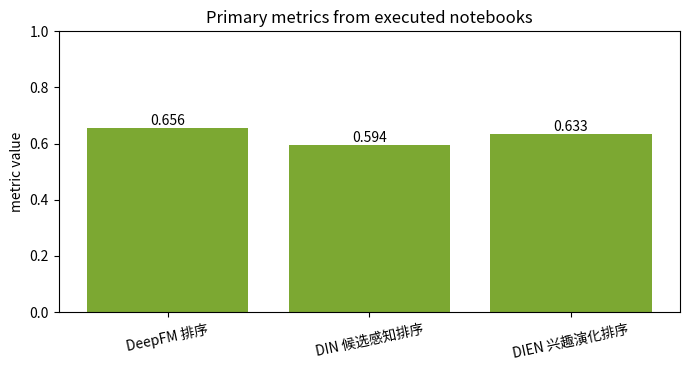

In [3]:
from matplotlib import font_manager

# Matplotlib 默认的 DejaVu Sans 不包含中文字形。优先选择容器中安装的
# Noto CJK；在精简宿主机上找不到中文字体时，退回纯 ASCII 的 Notebook 编号，
# 从根源避免 missing glyph 警告，而不是用 warnings.filterwarnings 隐藏它。
cjk_candidates = ('Noto Sans CJK SC', 'Noto Sans CJK JP', 'Microsoft YaHei', 'SimHei', 'PingFang SC')
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
cjk_font = next((name for name in cjk_candidates if name in installed_fonts), None)
if cjk_font:
    plt.rcParams['font.sans-serif'] = [cjk_font, 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
chart_labels = comparison.algorithm if cjk_font else comparison.source_notebook
print('图表字体:', cjk_font or 'ASCII fallback（宿主机未安装 CJK 字体）')

fig,ax=plt.subplots(figsize=(max(7,len(comparison)*1.5),3.8))
bars=ax.bar(chart_labels,comparison.primary_value,color='#7ca832')
ax.set(title='Primary metrics from executed notebooks',ylabel='metric value',ylim=(0,max(1.0,comparison.primary_value.max()*1.18)))
ax.tick_params(axis='x',rotation=12)
for bar,value in zip(bars,comparison.primary_value): ax.text(bar.get_x()+bar.get_width()/2,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show()

## 与原论文的可比性审计

下表逐项核对本教程实际产物与论文表格。**“不可直接比较”不是回避差距**：候选集合、样本规模、切分和指标任一不同，数值相减就没有统计含义。这里同时指出当前实验能证明什么、不能证明什么。

In [4]:
paper_audit = pd.DataFrame([{'algorithm': 'DeepFM', 'tutorial_result': 'KuaiRand AUC=0.6770；LogLoss=0.7136', 'paper_result': 'Criteo AUC=0.8007；LogLoss=0.45083', 'paper_protocol': 'Criteo 约 4,584 万样本、39 个 field；400×3 MLP、dropout 0.5', 'verdict': '不可直接比较数据集绝对值；当前 7,000 行 smoke 实验高于简化 LR，但样本与特征远少于论文。'}, {'algorithm': 'DIN', 'tutorial_result': 'KuaiRand AUC=0.5938；LogLoss=1.4411', 'paper_result': 'Amazon Electronics AUC=0.8871；Alibaba AUC=0.6083', 'paper_protocol': 'Amazon 1,689,188 样本；工业训练约 20 亿样本，含 Dice 与 MBA 正则化', 'verdict': '未建立论文级效果：2,600 行全批训练过拟合且概率失准；只说明 target-aware 路径可运行。'}, {'algorithm': 'DIEN', 'tutorial_result': 'KuaiRand AUC=0.6335；LogLoss=0.5709', 'paper_result': 'Electronics AUC=0.7792；Books AUC=0.8453；工业 AUC=0.6541', 'paper_protocol': '公开集约 19/60 万用户；工业 70 亿样本，AUGRU + 辅助损失，5 次重复', 'verdict': '不可跨数据集比较绝对值；当前优于同口径 DIN，但规模、特征与训练策略远未对齐。'}])
display(paper_audit)
print('结论：当前结果是可执行的 smoke/教学实验，不是 paper reproduction。')

,algorithm,tutorial_result,paper_result,paper_protocol,verdict
0,DeepFM,KuaiRand AUC=0.6770；LogLoss=0.7136,Criteo AUC=0.8007；LogLoss=0.45083,"Criteo 约 4,584 万样本、39 个 field；400×3 MLP、dropou...","不可直接比较数据集绝对值；当前 7,000 行 smoke 实验高于简化 LR，但样本与特征..."
1,DIN,KuaiRand AUC=0.5938；LogLoss=1.4411,Amazon Electronics AUC=0.8871；Alibaba AUC=0.6083,"Amazon 1,689,188 样本；工业训练约 20 亿样本，含 Dice 与 MBA 正则化","未建立论文级效果：2,600 行全批训练过拟合且概率失准；只说明 target-aware ..."
2,DIEN,KuaiRand AUC=0.6335；LogLoss=0.5709,Electronics AUC=0.7792；Books AUC=0.8453；工业 AUC...,公开集约 19/60 万用户；工业 70 亿样本，AUGRU + 辅助损失，5 次重复,不可跨数据集比较绝对值；当前优于同口径 DIN，但规模、特征与训练策略远未对齐。


结论：当前结果是可执行的 smoke/教学实验，不是 paper reproduction。


## Takeaways

DeepFM 处理静态 field 交互；DIN 让历史随候选变化；DIEN 再利用次序。复杂模型不保证胜出，AUC、LogLoss、GAUC 与 P99 必须同时评估。

先固定业务阶段和候选口径，再比较主指标、辅助指标、baseline 与系统成本。smoke 数值用于代码回归和学习，不能跨数据或跨公司宣称优劣。

## Checks

In [5]:
assert len(comparison)==3
assert comparison.source_notebook.nunique()==3
assert comparison.primary_value.between(0,1).all()
print('PASS：总结完全来自独立 Notebook 的执行产物。')

PASS：总结完全来自独立 Notebook 的执行产物。


## Next Steps

在相同完整数据、时间切分、负样本和候选集上重跑；加入效果—延迟—成本三维表，再决定是否进入线上 A/B。